In [1]:
import pandas as pd
from neuron import h
from plastic_neuron import PlasticNeuron
from abstract_neuron import AbstractNeuron
import numpy as np
from neuron_utils import NeuronUtils
from neuron_plots import NeuronPlots
import matplotlib.pyplot as plt

# TI influence on subthreshold synaptic plasticity

Soma is inhibited by inhibitory basket cell:

- soma / proximal apical dendrites
- GABAergic (GABA A - fast inhibition)
- activated a few ms after CA3 inputs

After, model CA3 synapses at the strength that results in LTP. EPSPs in the dendritic tree should be relatively large.

In [2]:
def generate_poisson(
        frequency = 5,
        burst_duration = 50,
        duration = 1000,
        rate_in_burst = 100,
        rate_outside_burst = 1
):
    burst_times = np.arange(0, duration, 1000 / frequency)
    spike_times = []

    for t_burst in burst_times:
        # Generate Poisson spikes inside the burst window
        n_spikes = np.random.poisson(rate_in_burst * (burst_duration / 1000))
        spikes = t_burst + np.random.uniform(0, burst_duration, size = n_spikes)
        spike_times.extend(spikes)

        # Generate sparse spikes outside bursts
        outside_duration = (1000 / frequency) - burst_duration
        if outside_duration > 0:
            n_out = np.random.poisson(rate_outside_burst * (outside_duration / 1000))
            spikes_out = t_burst + burst_duration + np.random.uniform(0, outside_duration, size = n_out)
            spike_times.extend(spikes_out)

    spike_times = np.sort(np.array(spike_times))
    return spike_times

In [3]:
rate = 5
duration = 1 * 1000 # ms

In [4]:
# Generate a list of random seeds to use when generating stimuli
np.random.seed(175204)
seeds = np.random.choice(range(10000), 20, replace = False)

seed_counter = -1


# Define the stimulus
def poisson_theta():
    global seed_counter
    seed_counter += 1

    np.random.seed(seeds[seed_counter])

    # Generate spike times
    spike_times = generate_poisson(frequency = rate, duration = duration)
    spike_vec = h.Vector(spike_times)

    stimulus = h.VecStim()
    stimulus.play(spike_vec)

    return stimulus

In [5]:
def create_constant_freq_stimulus():
    frequency = 5
    noise = 0
    delay = 0

    stimulus = h.NetStim()
    stimulus.interval = int(1000 / frequency)
    stimulus.noise = noise
    stimulus.start = delay

    return stimulus

In [6]:
neuron = PlasticNeuron(
    seed = 175204,
    n_synapses = 2,
    initial_weight = 0.5,
    initial_conductance = 0.0001,
    generate_stimulus = create_constant_freq_stimulus,
    # Define parameters of the basket cells
    basket_n_synapses = 15,
    basket_generate_delay = lambda: 3,
    basket_generate_stimulus = create_constant_freq_stimulus,
    basket_conductance = 0.005,
    basket_max_distance = 75,
    basket_fraction = dict({
        "Soma": 1,
        "Basal": 0,
        "Apical": 0
    })
)

Creating cell
	1 
	1 
	0 
23 
After any change to cell geometry or nseg, be sure to invoke setpointers()
Generating synapse information
Inserting 2 synapses
Inserting 15 inhibitory basket synapses
Inserting basket cell in compartment: Soma
Inserting basket cell in compartment: Soma
Inserting basket cell in compartment: Soma
Inserting basket cell in compartment: Soma
Inserting basket cell in compartment: Soma
Inserting basket cell in compartment: Soma
Inserting basket cell in compartment: Soma
Inserting basket cell in compartment: Soma
Inserting basket cell in compartment: Soma
Inserting basket cell in compartment: Soma
Inserting basket cell in compartment: Soma
Inserting basket cell in compartment: Soma
Inserting basket cell in compartment: Soma
Inserting basket cell in compartment: Soma
Inserting basket cell in compartment: Soma


In [7]:
neuron.basket_synapse_info

,Compartment,CompartmentID,Location,Distance,Delay,Conductance
0,Soma,0,0.399485,7.851,3,0.005
1,Soma,0,0.745146,7.851,3,0.005
2,Soma,0,0.131064,7.851,3,0.005
3,Soma,0,0.128369,7.851,3,0.005
4,Soma,0,0.809093,7.851,3,0.005
5,Soma,0,0.097353,7.851,3,0.005
6,Soma,0,0.016046,7.851,3,0.005
7,Soma,0,0.873650,7.851,3,0.005
8,Soma,0,0.380685,7.851,3,0.005
9,Soma,0,0.478801,7.851,3,0.005


## Simulation without TI

In [8]:
NeuronUtils.set_stimulus(duration = 0)
neuron.run(duration = duration)

Neuron initialized
Elapsed time: 23.29 seconds


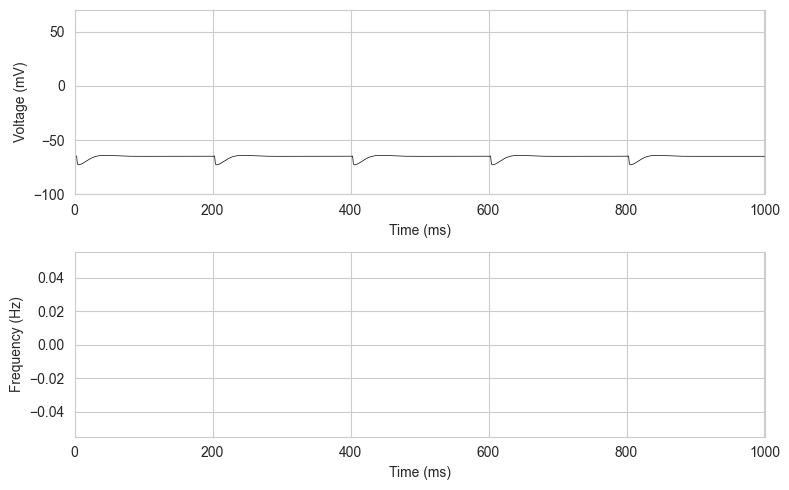

In [9]:
NeuronPlots.plot_spike_frequency(neuron)

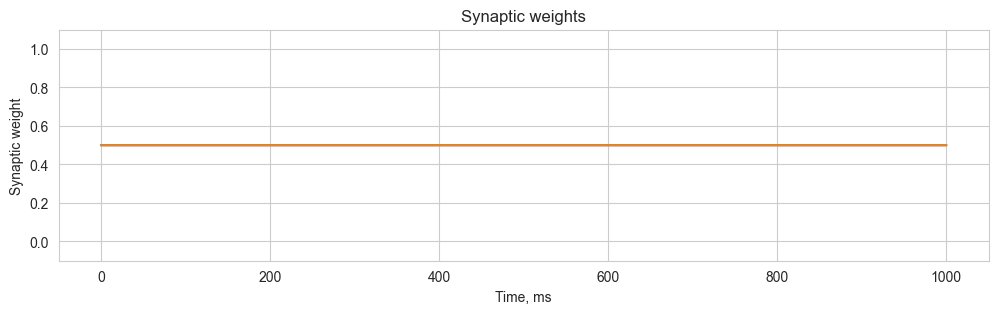

In [10]:
plt.figure(figsize = (12, 3))
NeuronPlots.plot_synaptic_weights(neuron)

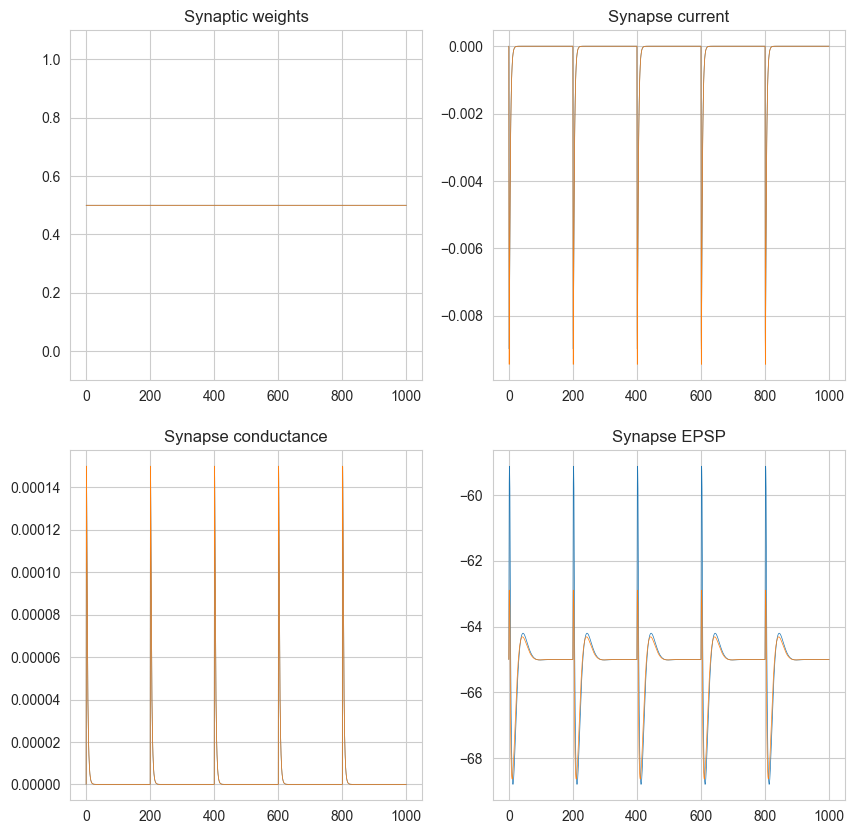

In [11]:
NeuronPlots.plot_all_synapses(neuron)

### Synapse EPSP

In [12]:
synapse = neuron.synapses[0]

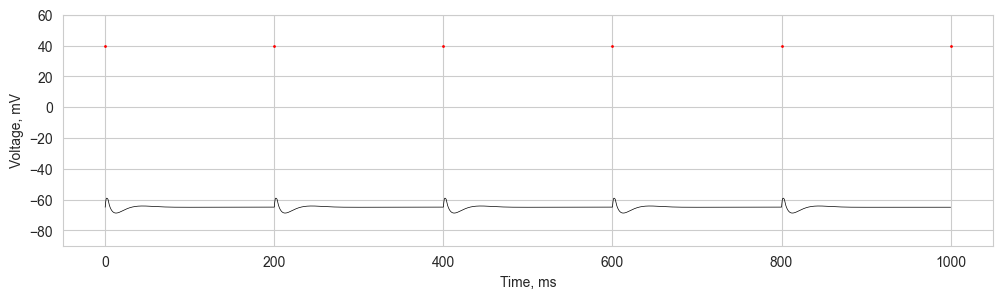

In [13]:
plt.figure(figsize = (12, 3))

plt.plot(
    neuron.time,
    synapse.voltage,
    linewidth = 0.5,
    color = "black"
)

plt.xlabel("Time, ms")
plt.ylabel("Voltage, mV")
plt.ylim(-90, 60)

plt.scatter(
    synapse.stimuli,
    np.repeat(40, len(synapse.stimuli)),
    c = "red",
    s = 1
)

plt.show()

In [14]:
from scipy.signal import butter, lfilter


def causal_bandpass(data, fs, lowcut = 1.0, highcut = 30.0, order = 2):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq

    b, a = butter(order, [low, high], btype = "band")
    return lfilter(b, a, data)

In [15]:
ms_before = 50
ms_after = 100

epsps = []
fs = int(1 / (neuron.time[1] - neuron.time[0]) * 1000)

expected_len = sum(np.logical_and(neuron.time >= 0, neuron.time < ms_before + ms_after))

for synapse in neuron.synapses:
    synapse_epsps = []

    synapse_voltage = causal_bandpass(synapse.voltage, lowcut = 1, highcut = 100, fs = fs, order = 2)
    # synapse_voltage = synapse.voltage
    
    for stimulus in synapse.stimuli:
        start = stimulus - ms_before
        end = stimulus + ms_after

        if start < 0 or end > neuron.time[-1]:
            continue

        time_idx = np.where(np.logical_and(neuron.time > start, neuron.time <= end))[0]
        while len(time_idx) < expected_len:
            time_idx = np.append(time_idx, time_idx[-1] + 1)
        while len(time_idx) > expected_len:
            time_idx = time_idx[:-1]
            
        synapse_epsps.append(synapse_voltage[ time_idx ])

    synapse_epsps = np.array(synapse_epsps)
    epsps.append(synapse_epsps)

time = neuron.time[ np.where(np.logical_and(neuron.time >= 0, neuron.time < ms_before + ms_after))[0] ]

if epsps[0].shape[1] != time.shape[0]:
    time = time[:-1]

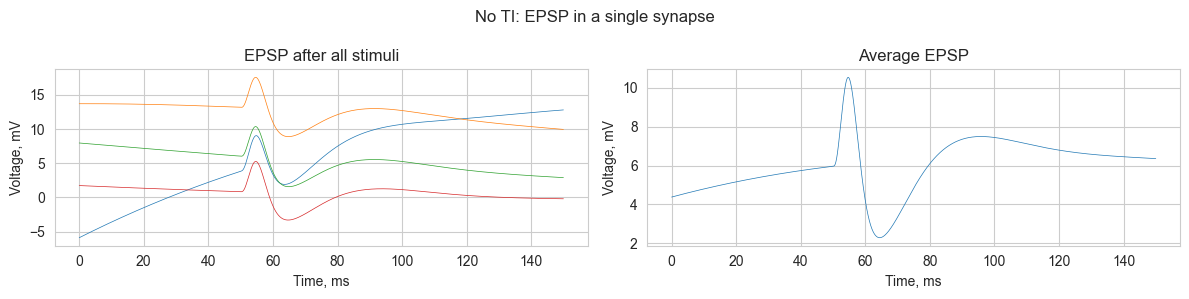

In [16]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 3))

for epsp in epsps[0]:
    axs[0].plot(
        time,
        epsp,
        linewidth = 0.5
    )

axs[0].set_xlabel("Time, ms")
axs[0].set_ylabel("Voltage, mV")
axs[0].set_title("EPSP after all stimuli")

axs[1].plot(
    time,
    np.mean(epsps[0], axis = 0),
    linewidth = 0.5
)

axs[1].set_xlabel("Time, ms")
axs[1].set_ylabel("Voltage, mV")
axs[1].set_title("Average EPSP")

fig.suptitle("No TI: EPSP in a single synapse")
fig.tight_layout()

plt.show()

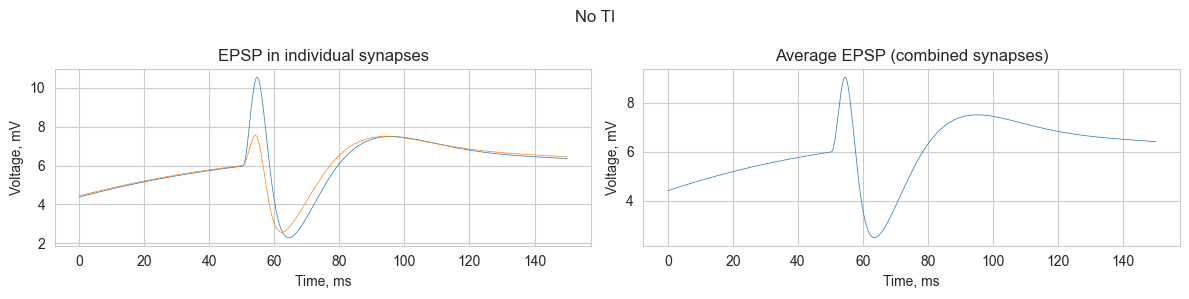

In [17]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 3))

for synapse_epsps in epsps:
    axs[0].plot(
        time,
        np.mean(synapse_epsps, axis = 0),
        linewidth = 0.5
    )

axs[0].set_xlabel("Time, ms")
axs[0].set_ylabel("Voltage, mV")
axs[0].set_title("EPSP in individual synapses")

epsp_means = []
for synapse_epsps in epsps:
    epsp_means.append(np.mean(synapse_epsps, axis = 0))

epsp_means = np.array(epsp_means)

axs[1].plot(
    time,
    np.mean(epsp_means, axis = 0),
    linewidth = 0.5
)

axs[1].set_xlabel("Time, ms")
axs[1].set_ylabel("Voltage, mV")
axs[1].set_title("Average EPSP (combined synapses)")

fig.suptitle("No TI")
fig.tight_layout()

plt.show()

## Simulation with TI (5 Hz)

In [18]:
NeuronUtils.set_stimulus(
    duration = duration,
    frequency1 = 1000,
    frequency2 = 1005,
    amplitude = 134,
    delay = 0,
    phase = 10
)

neuron.run(duration = duration)

Neuron initialized
Elapsed time: 23.14 seconds


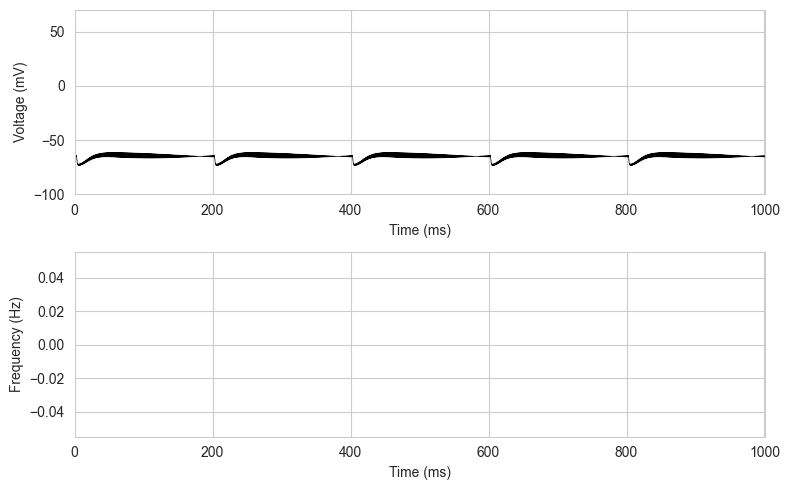

In [19]:
NeuronPlots.plot_spike_frequency(neuron)

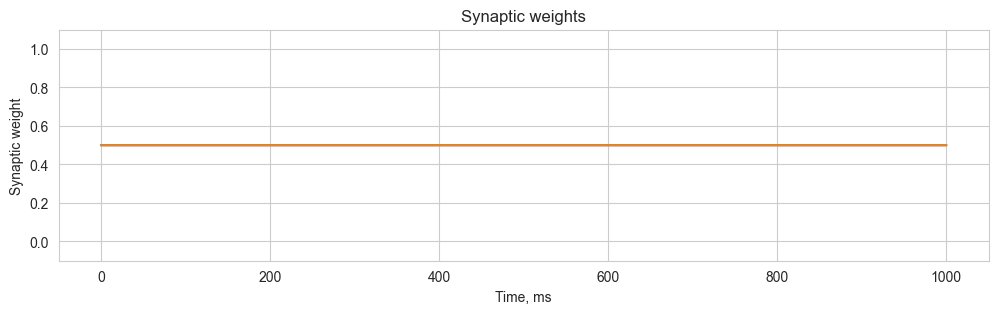

In [20]:
plt.figure(figsize = (12, 3))
NeuronPlots.plot_synaptic_weights(neuron)

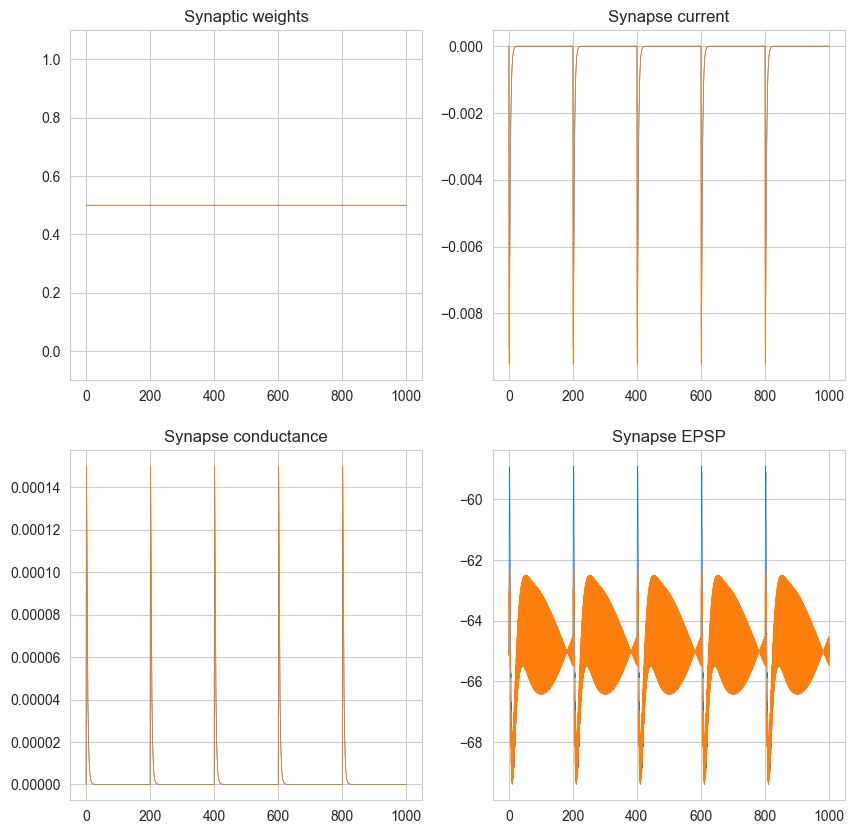

In [21]:
NeuronPlots.plot_all_synapses(neuron)

### Synapse EPSP

In [22]:
synapse = neuron.synapses[0]

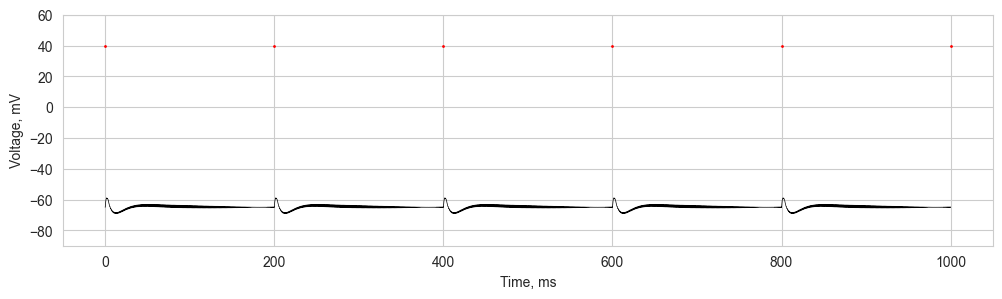

In [23]:
plt.figure(figsize = (12, 3))

plt.plot(
    neuron.time,
    synapse.voltage,
    linewidth = 0.5,
    color = "black"
)

plt.xlabel("Time, ms")
plt.ylabel("Voltage, mV")
plt.ylim(-90, 60)

plt.scatter(
    synapse.stimuli,
    np.repeat(40, len(synapse.stimuli)),
    c = "red",
    s = 1
)

plt.show()

In [24]:
ms_before = 50
ms_after = 100

epsps_ti = []
fs = int(1 / (neuron.time[1] - neuron.time[0]) * 1000)

expected_len = sum(np.logical_and(neuron.time >= 0, neuron.time < ms_before + ms_after))

for synapse in neuron.synapses:
    synapse_epsps = []

    synapse_voltage = causal_bandpass(synapse.voltage, lowcut = 1, highcut = 100, fs = fs, order = 2)
    # synapse_voltage = synapse.voltage

    for stimulus in synapse.stimuli:
        start = stimulus - ms_before
        end = stimulus + ms_after
    
        if start < 0 or end > np.max(neuron.time):
            continue
    
        time_idx = np.where(np.logical_and(neuron.time >= start, neuron.time <= end))[0]
        while len(time_idx) < expected_len:
            time_idx = np.append(time_idx, time_idx[-1] + 1)
        while len(time_idx) > expected_len:
            time_idx = time_idx[:-1]
        
        synapse_epsps.append(synapse_voltage[ time_idx ])
    
    synapse_epsps = np.array(synapse_epsps)
    epsps_ti.append(synapse_epsps)

time = neuron.time[ np.where(np.logical_and(neuron.time >= 0, neuron.time < ms_before + ms_after))[0] ]

if epsps_ti[0].shape[1] != time.shape[0]:
    time = time[:-1]

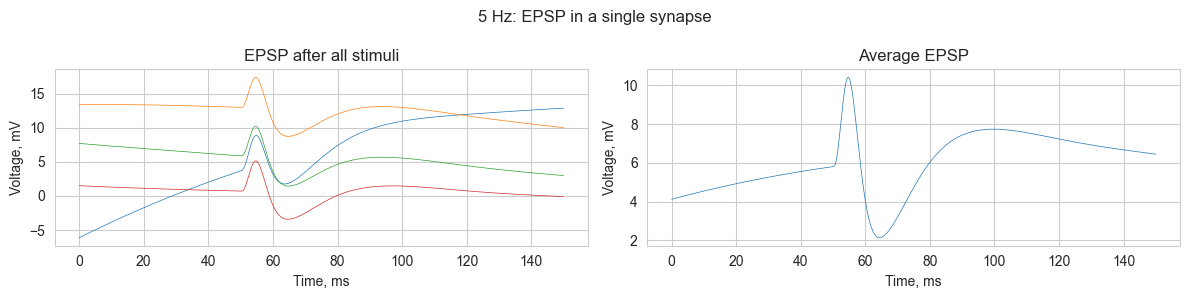

In [25]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 3))

for epsp in epsps_ti[0]:
    axs[0].plot(
        time,
        epsp,
        linewidth = 0.5
    )

axs[0].set_xlabel("Time, ms")
axs[0].set_ylabel("Voltage, mV")
axs[0].set_title("EPSP after all stimuli")

axs[1].plot(
    time,
    np.mean(epsps_ti[0], axis = 0),
    linewidth = 0.5
)

axs[1].set_xlabel("Time, ms")
axs[1].set_ylabel("Voltage, mV")
axs[1].set_title("Average EPSP")

fig.suptitle("5 Hz: EPSP in a single synapse")
fig.tight_layout()

plt.show()

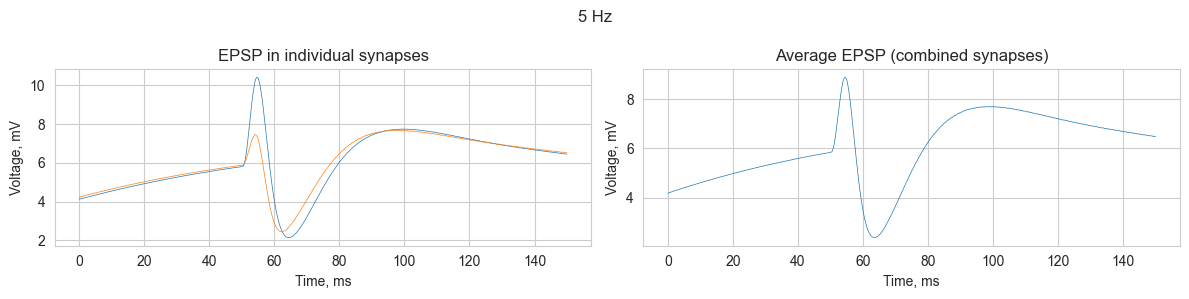

In [26]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 3))

for synapse_epsps in epsps_ti:
    axs[0].plot(
        time,
        np.mean(synapse_epsps, axis = 0),
        linewidth = 0.5
    )

axs[0].set_xlabel("Time, ms")
axs[0].set_ylabel("Voltage, mV")
axs[0].set_title("EPSP in individual synapses")

epsp_means_ti = []
for synapse_epsps in epsps_ti:
    epsp_means_ti.append(np.mean(synapse_epsps, axis = 0))

epsp_means_ti = np.array(epsp_means_ti)

axs[1].plot(
    time,
    np.mean(epsp_means_ti, axis = 0),
    linewidth = 0.5
)

axs[1].set_xlabel("Time, ms")
axs[1].set_ylabel("Voltage, mV")
axs[1].set_title("Average EPSP (combined synapses)")

fig.suptitle("5 Hz")
fig.tight_layout()

plt.show()

## Simulation with TI (130 Hz)

In [43]:
NeuronUtils.set_stimulus(
    duration = duration,
    frequency1 = 1000,
    frequency2 = 1130,
    amplitude = 165,
    delay = 0,
    phase = 10
)

neuron.run(duration = duration)

Neuron initialized
Elapsed time: 23.45 seconds


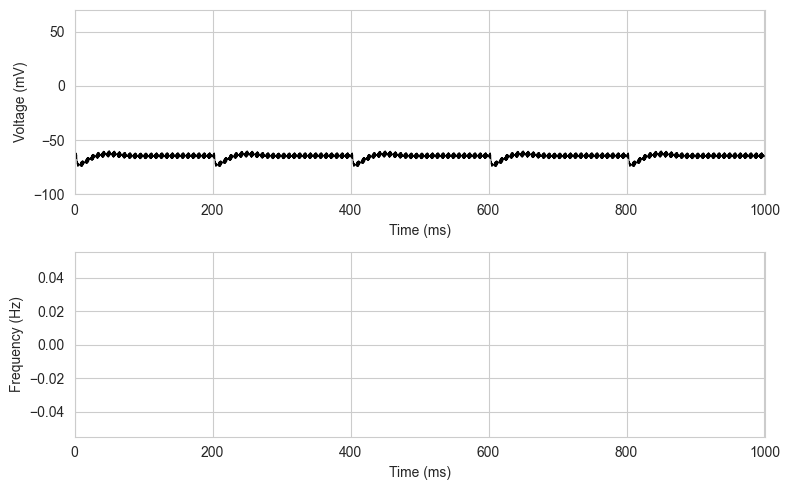

In [44]:
NeuronPlots.plot_spike_frequency(neuron)

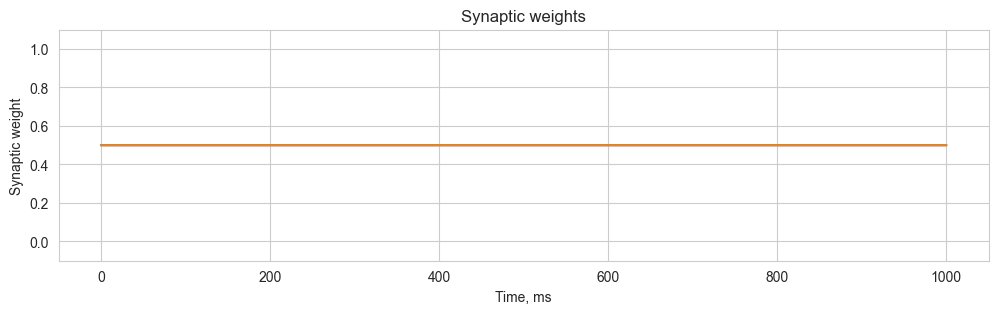

In [45]:
plt.figure(figsize = (12, 3))
NeuronPlots.plot_synaptic_weights(neuron)

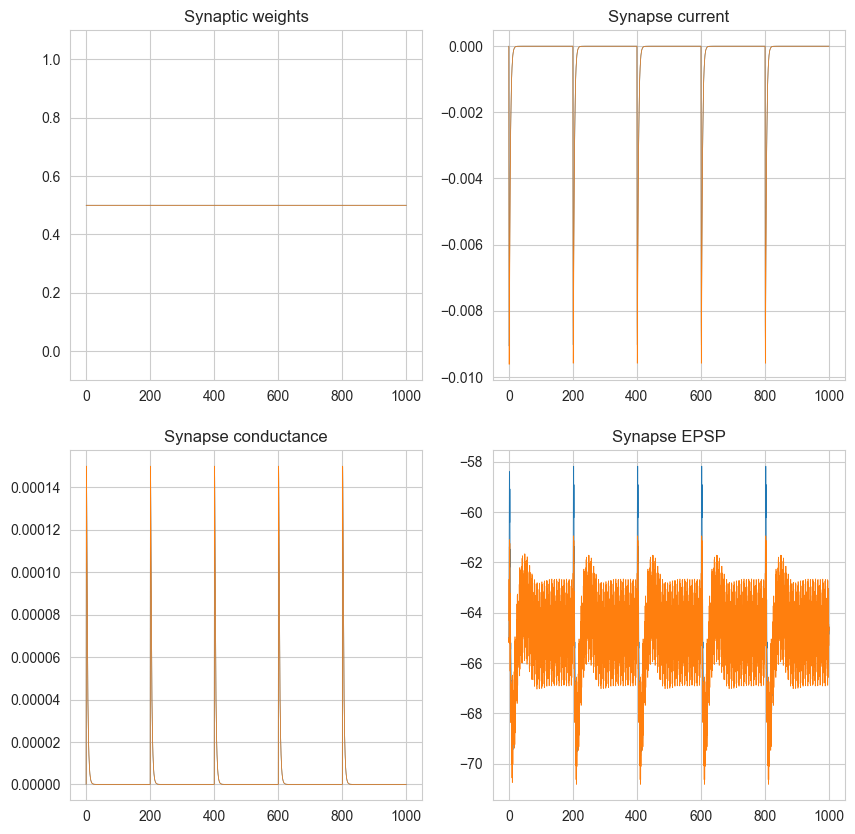

In [46]:
NeuronPlots.plot_all_synapses(neuron)

### Synapse EPSP

In [47]:
synapse = neuron.synapses[0]

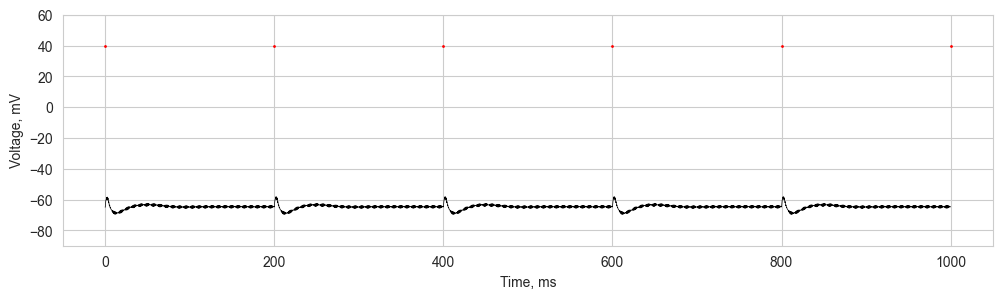

In [48]:
plt.figure(figsize = (12, 3))

plt.plot(
    neuron.time,
    synapse.voltage,
    linewidth = 0.5,
    color = "black"
)

plt.xlabel("Time, ms")
plt.ylabel("Voltage, mV")
plt.ylim(-90, 60)

plt.scatter(
    synapse.stimuli,
    np.repeat(40, len(synapse.stimuli)),
    c = "red",
    s = 1
)

plt.show()

In [49]:
ms_before = 50
ms_after = 100

epsps_ti_130 = []
fs = int(1 / (neuron.time[1] - neuron.time[0]) * 1000)

expected_len = sum(np.logical_and(neuron.time >= 0, neuron.time < ms_before + ms_after))

for synapse in neuron.synapses:
    synapse_epsps = []

    synapse_voltage = causal_bandpass(synapse.voltage, lowcut = 1, highcut = 100, fs = fs, order = 2)
    # synapse_voltage = synapse.voltage

    for stimulus in synapse.stimuli:
        start = stimulus - ms_before
        end = stimulus + ms_after

        if start < 0 or end > np.max(neuron.time):
            continue

        time_idx = np.where(np.logical_and(neuron.time >= start, neuron.time <= end))[0]
        while len(time_idx) < expected_len:
            time_idx = np.append(time_idx, time_idx[-1] + 1)
        while len(time_idx) > expected_len:
            time_idx = time_idx[:-1]
        
        synapse_epsps.append(synapse_voltage[ time_idx ])

    synapse_epsps = np.array(synapse_epsps)
    epsps_ti_130.append(synapse_epsps)

time = neuron.time[ np.where(np.logical_and(neuron.time >= 0, neuron.time < ms_before + ms_after))[0] ]

if epsps_ti_130[0].shape[1] != time.shape[0]:
    time = time[:-1]

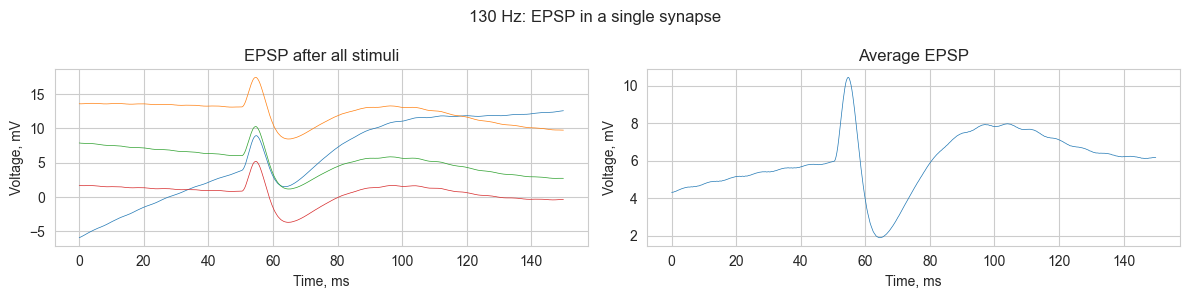

In [50]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 3))

for epsp in epsps_ti_130[0]:
    axs[0].plot(
        time,
        epsp,
        linewidth = 0.5
    )

axs[0].set_xlabel("Time, ms")
axs[0].set_ylabel("Voltage, mV")
axs[0].set_title("EPSP after all stimuli")

axs[1].plot(
    time,
    np.mean(epsps_ti_130[0], axis = 0),
    linewidth = 0.5
)

axs[1].set_xlabel("Time, ms")
axs[1].set_ylabel("Voltage, mV")
axs[1].set_title("Average EPSP")

fig.suptitle("130 Hz: EPSP in a single synapse")
fig.tight_layout()

plt.show()

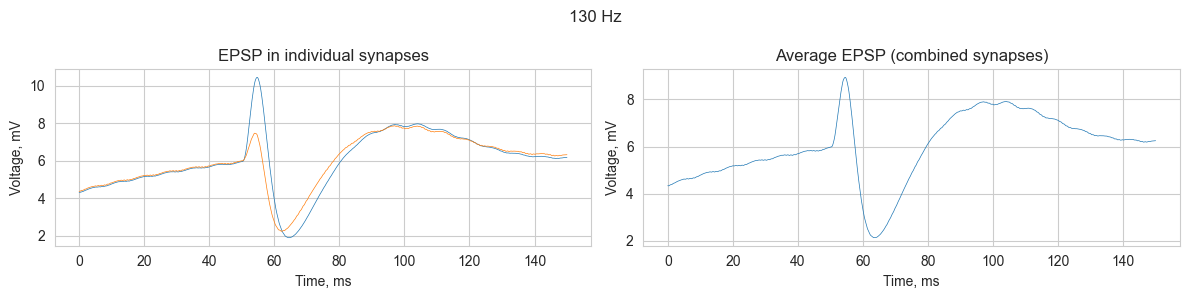

In [51]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 3))

for synapse_epsps in epsps_ti_130:
    axs[0].plot(
        time,
        np.mean(synapse_epsps, axis = 0),
        linewidth = 0.5
    )

axs[0].set_xlabel("Time, ms")
axs[0].set_ylabel("Voltage, mV")
axs[0].set_title("EPSP in individual synapses")

epsp_means_ti_130 = []
for synapse_epsps in epsps_ti_130:
    epsp_means_ti_130.append(np.mean(synapse_epsps, axis = 0))

epsp_means_ti_130 = np.array(epsp_means_ti_130)

axs[1].plot(
    time,
    np.mean(epsp_means_ti_130, axis = 0),
    linewidth = 0.5
)

axs[1].set_xlabel("Time, ms")
axs[1].set_ylabel("Voltage, mV")
axs[1].set_title("Average EPSP (combined synapses)")

fig.suptitle("130 Hz")
fig.tight_layout()

plt.show()

## Quick comparison of EPSPs

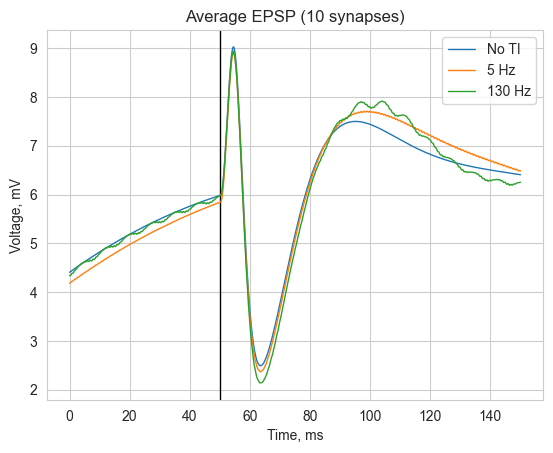

In [52]:
# plt.vlines(ms_before, ymin = -100, ymax = 100, linewidth = 1, color = "red")

plt.axvline(ms_before, linewidth = 1, color = "black")

plt.plot(
    time,
    np.mean(epsp_means, axis = 0),
    linewidth = 1,
    label = "No TI"
)

plt.plot(
    time,
    np.mean(epsp_means_ti, axis = 0),
    linewidth = 1,
    label = "5 Hz"
)

plt.plot(
    time,
    np.mean(epsp_means_ti_130, axis = 0),
    linewidth = 1,
    label = "130 Hz"
)

plt.xlabel("Time, ms")
plt.ylabel("Voltage, mV")
# plt.ylim(-70, -40)
plt.title("Average EPSP (10 synapses)")
plt.legend()
# plt.xlim(45, 60)

plt.show()

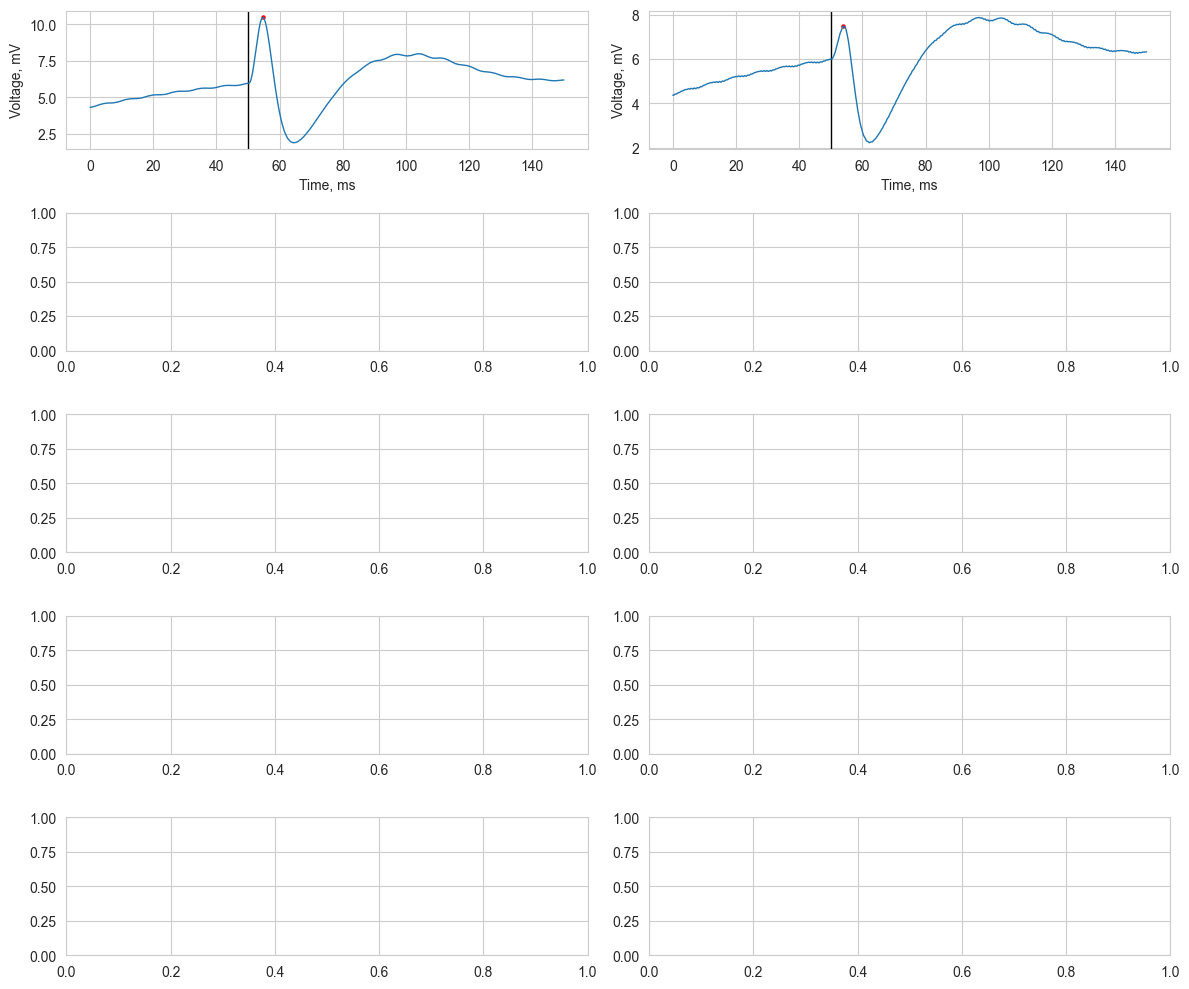

In [53]:
fig, axs = plt.subplots(nrows = 5, ncols = 2, figsize = (12, 2 * 5))
axs = axs.flatten()

max_time_ti_130 = []
max_voltage_ti_130 = []

for synapse_epsps, ax in zip(epsps_ti_130, axs):
    ax.axvline(ms_before, color = "black", linewidth = 1)
    mean_synapse_epsp = np.mean(synapse_epsps, axis = 0)
    
    ax.plot(
        time,
        mean_synapse_epsp,
        linewidth = 1
    )
    
    epsp_window = np.logical_and(time > 50, time < 60)
    epsp_time = time[epsp_window]
    epsp_voltage = mean_synapse_epsp[epsp_window]
    max_v_idx = np.argmax(epsp_voltage)
    
    ax.scatter(
        epsp_time[max_v_idx],
        epsp_voltage[max_v_idx],
        c = "red",
        s = 5
    )

    max_time_ti_130.append(epsp_time[max_v_idx])
    max_voltage_ti_130.append(epsp_voltage[max_v_idx])

    ax.set_xlabel("Time, ms")
    ax.set_ylabel("Voltage, mV")

fig.tight_layout()

plt.show()

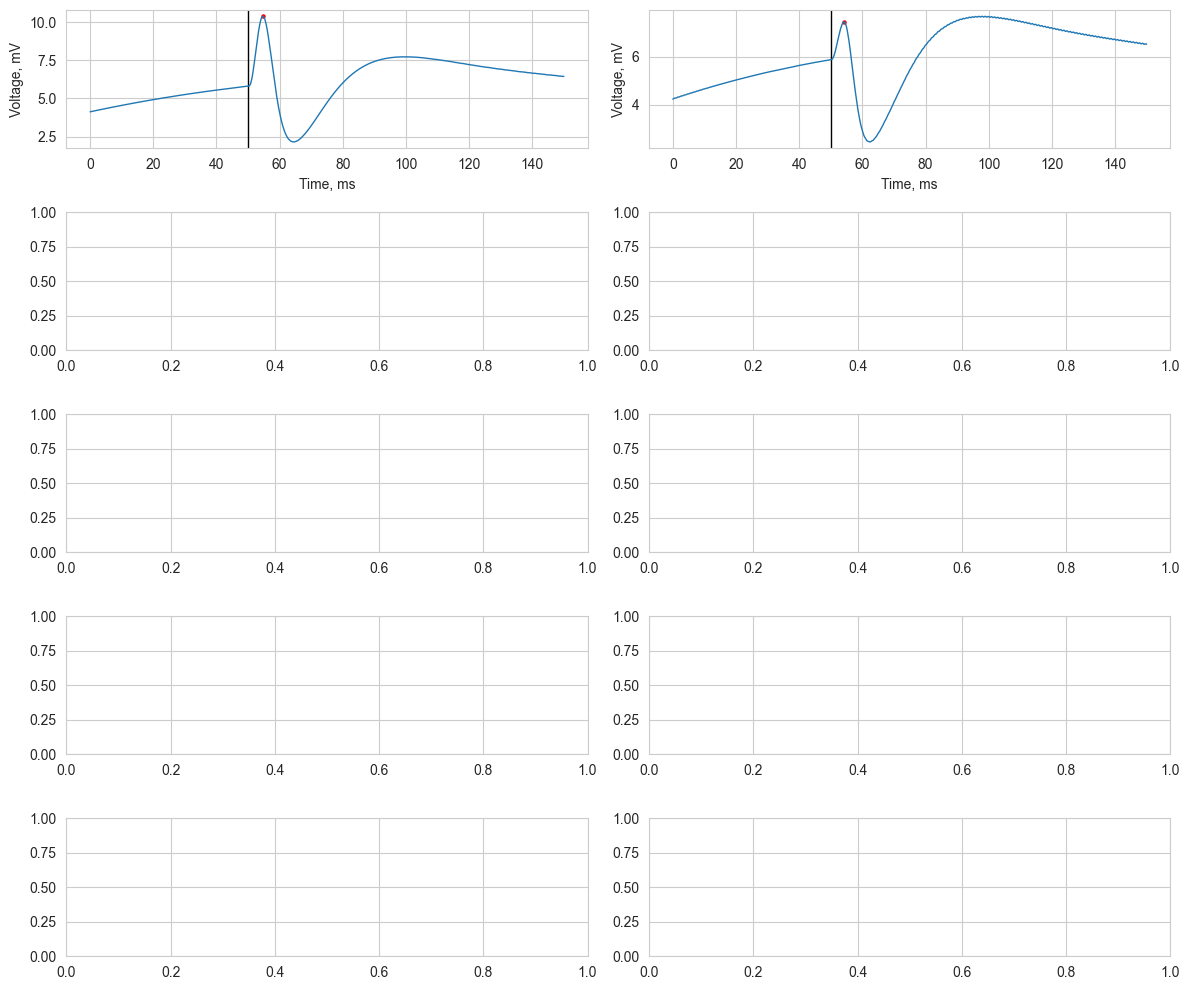

In [54]:
fig, axs = plt.subplots(nrows = 5, ncols = 2, figsize = (12, 2 * 5))
axs = axs.flatten()

max_time_ti = []
max_voltage_ti = []

for synapse_epsps, ax in zip(epsps_ti, axs):
    ax.axvline(ms_before, color = "black", linewidth = 1)
    mean_synapse_epsp = np.mean(synapse_epsps, axis = 0)

    ax.plot(
        time,
        mean_synapse_epsp,
        linewidth = 1
    )

    epsp_window = np.logical_and(time > 50, time < 60)
    epsp_time = time[epsp_window]
    epsp_voltage = mean_synapse_epsp[epsp_window]
    max_v_idx = np.argmax(epsp_voltage)

    ax.scatter(
        epsp_time[max_v_idx],
        epsp_voltage[max_v_idx],
        c = "red",
        s = 5
    )

    max_time_ti.append(epsp_time[max_v_idx])
    max_voltage_ti.append(epsp_voltage[max_v_idx])

    ax.set_xlabel("Time, ms")
    ax.set_ylabel("Voltage, mV")

fig.tight_layout()

plt.show()

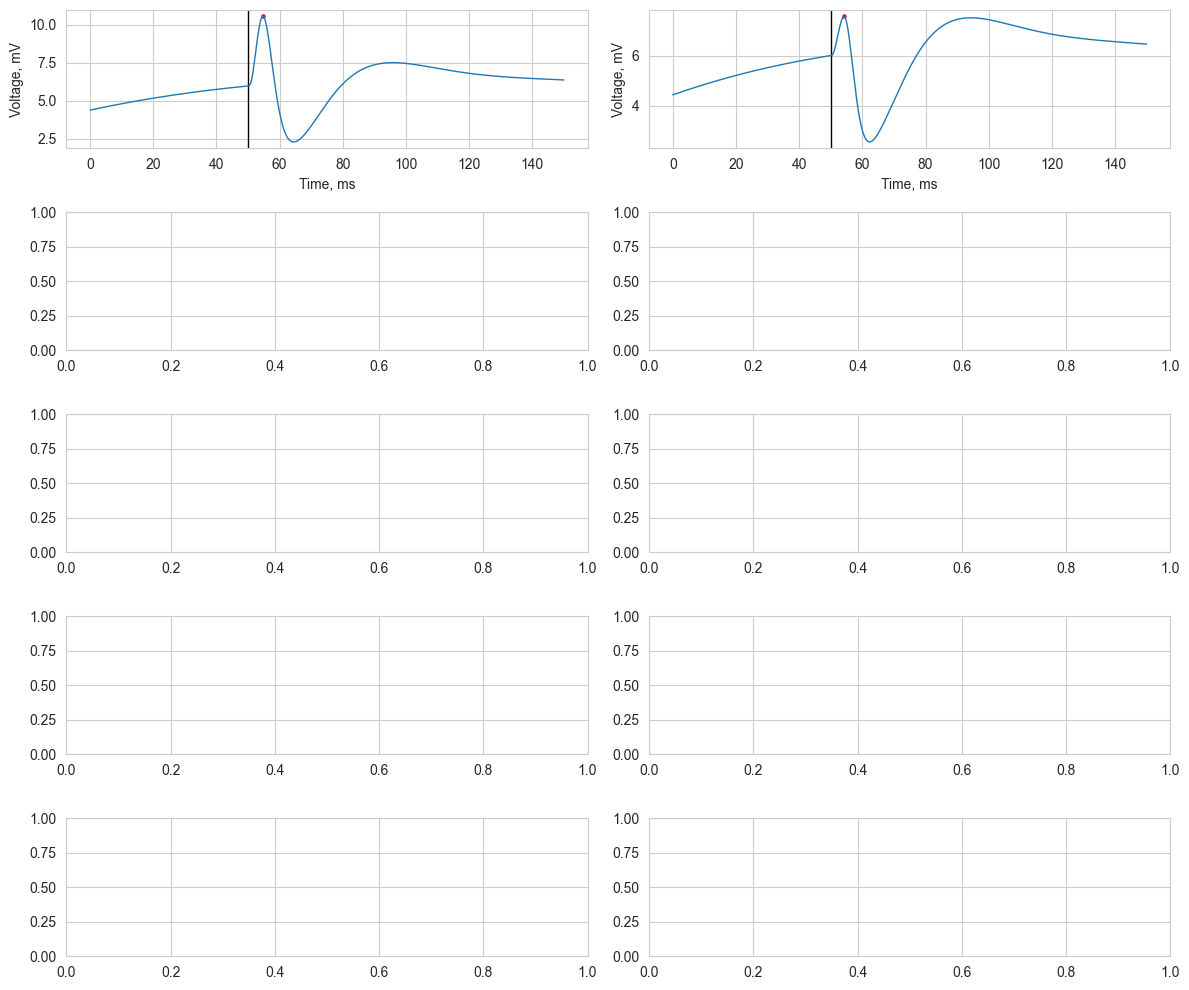

In [55]:
fig, axs = plt.subplots(nrows = 5, ncols = 2, figsize = (12, 2 * 5))
axs = axs.flatten()

max_time = []
max_voltage = []

for synapse_epsps, ax in zip(epsps, axs):
    ax.axvline(ms_before, color = "black", linewidth = 1)
    mean_synapse_epsp = np.mean(synapse_epsps, axis = 0)

    ax.plot(
        time,
        mean_synapse_epsp,
        linewidth = 1
    )

    epsp_window = np.logical_and(time > 50, time < 60)
    epsp_time = time[epsp_window]
    epsp_voltage = mean_synapse_epsp[epsp_window]
    max_v_idx = np.argmax(epsp_voltage)

    ax.scatter(
        epsp_time[max_v_idx],
        epsp_voltage[max_v_idx],
        c = "red",
        s = 5
    )

    max_time.append(epsp_time[max_v_idx])
    max_voltage.append(epsp_voltage[max_v_idx])

    ax.set_xlabel("Time, ms")
    ax.set_ylabel("Voltage, mV")

fig.tight_layout()

plt.show()

In [56]:
data = pd.concat([
    pd.DataFrame({
        "Condition": "No TI",
        "Voltage": max_voltage,
        "Time": max_time
    }),
    pd.DataFrame({
        "Condition": "5 Hz",
        "Voltage": max_voltage_ti,
        "Time": max_time_ti
    }),
    pd.DataFrame({
        "Condition": "130 Hz",
        "Voltage": max_voltage_ti_130,
        "Time": max_time_ti_130
    })
])

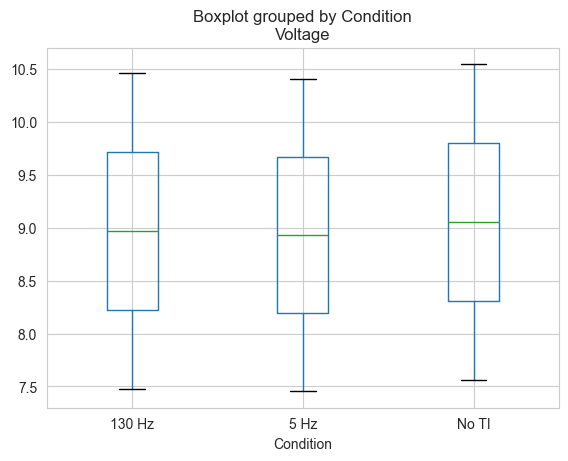

In [57]:
data.boxplot(
    by = "Condition",
    column = "Voltage"
)

plt.show()

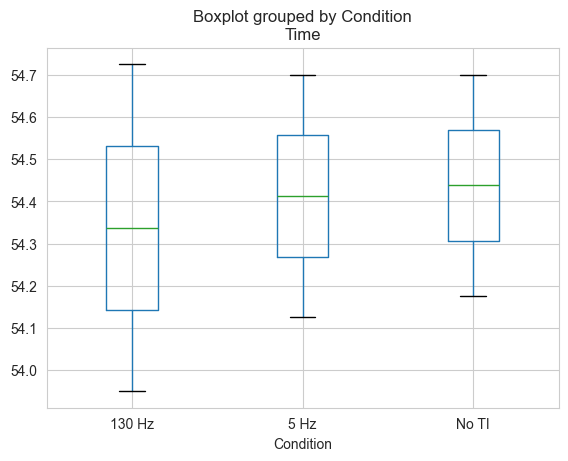

In [58]:
data.boxplot(
    by = "Condition",
    column = "Time"
)

plt.show()